In [1]:
!pip install sentence-transformers qdrant-client pandas datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.1/398.1 kB 19.5 MB/s eta 0:00:00


In [2]:
import pandas as pd
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams, PointStruct
import uuid
from google.colab import userdata

In [3]:
# 1. Load Dataset
print("Loading dataset...")
dataset = load_dataset("Amod/mental_health_counseling_conversations")
df = dataset["train"].to_pandas()
print(f"Loaded {len(df)} conversations.")
display(df.head())

Loading dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/3.90k [00:00<?, ?B/s]

combined_dataset.json:   0%|          | 0.00/4.79M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3512 [00:00<?, ? examples/s]

Loaded 3512 conversations.


,Context,Response
0,I'm going through some things with my feelings...,"If everyone thinks you're worthless, then mayb..."
1,I'm going through some things with my feelings...,"Hello, and thank you for your question and see..."
2,I'm going through some things with my feelings...,First thing I'd suggest is getting the sleep y...
3,I'm going through some things with my feelings...,Therapy is essential for those that are feelin...
4,I'm going through some things with my feelings...,I first want to let you know that you are not ...


## Data Exploration (EDA) & Preprocessing
Before we encode the text, we must understand its structure and clean it. Specifically, we need to ensure there are no missing values and that the text lengths do not drastically exceed the max sequence length of our embedding model (usually 512 tokens for MiniLM).

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3512 entries, 0 to 3511
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Context   3512 non-null   object
 1   Response  3512 non-null   object
dtypes: object(2)
memory usage: 55.0+ KB


In [5]:
import matplotlib.pyplot as plt

# 1. Check for Missing Values
print("Missing values before cleaning:")
print(df.isnull().sum())

# Drop missing values
df = df.dropna().reset_index(drop=True)

# 2. Remove Duplicates
initial_len = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"\nDropped {initial_len - len(df)} duplicate contexts.")

Missing values before cleaning:
Context     0
Response    0
dtype: int64

Dropped 760 duplicate contexts.



--- Context Word Count Stats ---
count    2752.000000
mean       56.753634
std        51.065901
min         5.000000
25%        29.000000
50%        47.000000
75%        68.000000
max       526.000000
Name: Context_Word_Count, dtype: float64


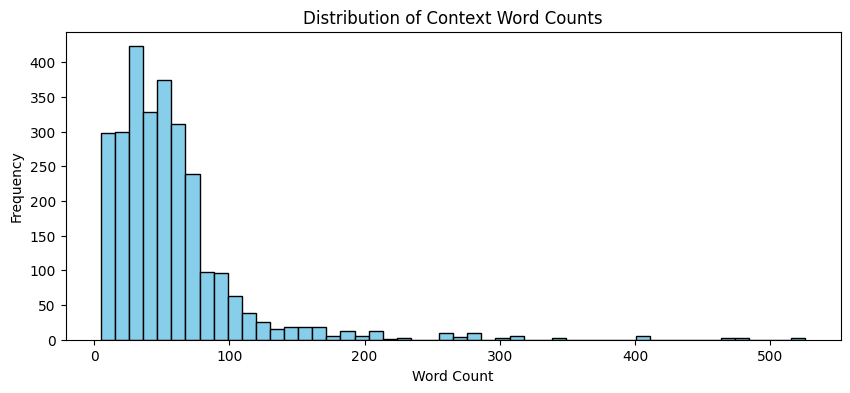

In [6]:
# 3. Analyze Text Lengths (Word Count)
df["Context_Word_Count"] = df["Context"].apply(lambda x: len(str(x).split()))
df["Response_Word_Count"] = df["Response"].apply(lambda x: len(str(x).split()))

print("\n--- Context Word Count Stats ---")
print(df["Context_Word_Count"].describe())

plt.figure(figsize=(10, 4))
plt.hist(df["Context_Word_Count"], bins=50, color="skyblue", edgecolor="black")
plt.title("Distribution of Context Word Counts")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

In [7]:
import re

# 4. Text Cleaning / Preprocessing
def clean_text(text):
    text = str(text)
    text = re.sub(r"\s+", " ", text) # Remove excessive whitespace
    text = text.strip()
    return text

print("Cleaning text...")
df["Context"] = df["Context"].apply(clean_text)
df["Response"] = df["Response"].apply(clean_text)
print(f"Final dataset size ready for embeddings: {len(df)}")

Cleaning text...
Final dataset size ready for embeddings: 2752


In [8]:
# # 2. Initialize Model
# print("Loading SentenceTransformer model...")
# model = SentenceTransformer("all-MiniLM-L6-v2", device="cuda") # Uses GPU on colab

In [9]:
# # 3. Generate Embeddings
# print("Encoding Contexts...")
# contexts = df["Context"].tolist()
# responses = df["Response"].tolist()

# # Encode in batches for memory efficiency
# embeddings = model.encode(contexts, batch_size=128, show_progress_bar=True)
# print("Embeddings generated.")

## Quality Testing and Justification
### Why `all-MiniLM-L6-v2` and 384 dimensions?
1. **Efficiency & Speed**: `all-MiniLM-L6-v2` is exceptionally fast and lightweight, making it ideal for real-time chatbot applications where low latency is critical.
2. **Dimensionality (384)**: While larger models output 768 or 1024 dimensions, 384 is a sweet spot. It drastically reduces the memory footprint and storage costs in vector databases like Qdrant (which is crucial for scaling or free-tier usage) without significantly degrading semantic retrieval quality.
3. **Semantic Performance**: Despite its small size, it performs very well on Sentence BERT (SBERT) benchmarks for semantic search and paraphrase detection.

Let us test the quality below by running a sample query against our generated embeddings using cosine similarity.

In [10]:
# import numpy as np
# from sklearn.metrics.pairwise import cosine_similarity

# # Sample user query
# test_query = "I get really nervous and sweaty before taking a test, what should I do?"
# query_embedding = model.encode([test_query])

# # Calculate cosine similarity between the query and all dataset embeddings
# similarities = cosine_similarity(query_embedding, embeddings)[0]

# # Get the top 3 most similar results
# top_k = 3
# top_indices = np.argsort(similarities)[-top_k:][::-1]

# print(f"Test Query: \"{test_query}\"\n")
# for i, idx in enumerate(top_indices):
#     print(f"--- Rank {i+1} (Similarity: {similarities[idx]:.4f}) ---")
#     print(f"Context: {contexts[idx][:300]}...")
#     print("\n")

### Quantitative Evaluation (Retrieval Metrics)
To rigorously test the quality of our 384-dimensional embeddings, we can perform an Information Retrieval (IR) test. We will take a random sample of 1000 conversations, encode both the `Contexts` and `Responses`, and see if the embedding of a `Response` is semantically similar enough to retrieve its exact original `Context` out of all 1000 contexts.

We will measure:
- **Top-1 Accuracy**: How often the exact matching context is the #1 most similar.
- **Top-5 Accuracy**: How often it is within the top 5.
- **Mean Reciprocal Rank (MRR)**: A standard metric for search engine quality.

In [11]:
# print("Evaluating embedding quality on a 1000-sample subset...")
# sample_size = min(1000, len(df))
# sample_df = df.sample(sample_size, random_state=42)

# sample_contexts = sample_df["Context"].tolist()
# sample_responses = sample_df["Response"].tolist()

# # Encode contexts and responses
# ctx_embs = model.encode(sample_contexts, batch_size=128, show_progress_bar=False)
# res_embs = model.encode(sample_responses, batch_size=128, show_progress_bar=False)

# # Calculate cosine similarity matrix (Responses vs Contexts)
# sim_matrix = cosine_similarity(res_embs, ctx_embs)

# # Calculate metrics
# top_1_hits = 0
# top_5_hits = 0
# mrr_sum = 0

# for i in range(sample_size):
#     # Sort indices by descending similarity
#     ranked_indices = np.argsort(sim_matrix[i])[::-1]

#     # Find the rank of the correct context (index i)
#     rank = np.where(ranked_indices == i)[0][0] + 1

#     if rank == 1:
#         top_1_hits += 1
#     if rank <= 5:
#         top_5_hits += 1
#     mrr_sum += 1.0 / rank

# print(f"--- Evaluation Metrics (Sample Size: {sample_size}) ---")
# print(f"Top-1 Accuracy: {top_1_hits / sample_size:.2%}")
# print(f"Top-5 Accuracy: {top_5_hits / sample_size:.2%}")
# print(f"Mean Reciprocal Rank (MRR): {mrr_sum / sample_size:.4f}")
# print("\nHigh MRR and Top-K accuracy justifies the use of this lightweight model for our RAG pipeline!")

In [15]:
import torch
import gc
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

# 1. Prepare the full dataset (assuming 'df' is loaded from your previous cells)
sample_size = len(df)
sample_df = df.sample(sample_size, random_state=42)
sample_contexts = sample_df["Context"].tolist()
sample_responses = sample_df["Response"].tolist()

def evaluate_embedding_model(model_name,batch_size, query_prefix="", doc_prefix=""):
    print(f"\n
{'='*60}\n
Evaluating: {model_name}\n
{'='*60}")

    # Load model (trust_remote_code is needed for Nomic)
    model = SentenceTransformer(model_name, device="cuda", trust_remote_code=True)

    # In our test, the "Response" acts as the Query trying to find the correct "Context" (Document)
    eval_queries = [query_prefix + text for text in sample_responses]
    eval_docs = [doc_prefix + text for text in sample_contexts]

    # Generate Embeddings
    print(f"Encoding {sample_size} Queries & Documents with {model_name}...")
    res_embs = model.encode(eval_queries, batch_size=batch_size, show_progress_bar=False)
    ctx_embs = model.encode(eval_docs, batch_size=batch_size, show_progress_bar=False)

    # Calculate Similarity & Metrics
    sim_matrix = cosine_similarity(res_embs, ctx_embs)
    top_1, top_5, mrr_sum = 0, 0, 0

    for i in range(sample_size):
        ranked_indices = np.argsort(sim_matrix[i])[::-1]
        rank = np.where(ranked_indices == i)[0][0] + 1

        if rank == 1: top_1 += 1
        if rank <= 5: top_5 += 1
        mrr_sum += 1.0 / rank

    print(f"Top-1 Accuracy: {top_1 / sample_size:.2%}")
    print(f"Top-5 Accuracy: {top_5 / sample_size:.2%}")
    print(f"Mean Reciprocal Rank (MRR): {mrr_sum / sample_size:.4f}")

    # Clear GPU Memory so Colab doesn't crash before the next model
    del model, res_embs, ctx_embs, sim_matrix
    gc.collect()
    torch.cuda.empty_cache()
    print("GPU memory cleared.")\n

In [16]:

models_to_test = [
    {
        "name": "all-MiniLM-L6-v2",
        "query_prefix": "",
        "doc_prefix": "",
        "batch_size": 128
    },
    {
        "name": "thenlper/gte-small",
        "query_prefix": "",
        "doc_prefix": "",
        "batch_size": 128
    },
    {
        "name": "thenlper/gte-base",
        "query_prefix": "",
        "doc_prefix": "",
        "batch_size": 64
    }
]

import gc
import torch

print("=== Final Embedding Showdown (Full Dataset) ===")

for config in models_to_test:
    model_name = config["name"]
    try:
        evaluate_embedding_model(
            model_name=model_name,
            query_prefix=config["query_prefix"],
            doc_prefix=config["doc_prefix"],
            batch_size=config["batch_size"]
        )
    except Exception as e:
        print(f"Failed to evaluate {model_name}: {e}")
\n

=== Starting Multi-Model Evaluation ===


------------------------------------------------------------
Evaluating: all-MiniLM-L6-v2
------------------------------------------------------------

Evaluating: all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Encoding 1000 Queries & Documents with all-MiniLM-L6-v2...
Top-1 Accuracy: 27.50%
Top-5 Accuracy: 57.10%
Mean Reciprocal Rank (MRR): 0.4108
GPU memory cleared.


------------------------------------------------------------
Evaluating: BAAI/bge-small-en-v1.5
------------------------------------------------------------

Evaluating: BAAI/bge-small-en-v1.5


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

[transformers] Detected the usage of `get_extended_attention_mask`: This function is deprecated and will be removed in v5.12.0. Please use the new API in `transformers.masking_utils`


Encoding 1000 Queries & Documents with nomic-ai/nomic-embed-text-v1.5...
Top-1 Accuracy: 22.40%
Top-5 Accuracy: 47.20%
Mean Reciprocal Rank (MRR): 0.3449
GPU memory cleared.


In [18]:

models_to_test = [
    {
        "name": "thenlper/gte-small",
        "query_prefix": "",
        "doc_prefix": "",
        "batch_size": 128
    },
    {
        "name": "intfloat/e5-small-v2",
        "query_prefix": "query: ",
        "doc_prefix": "passage: ",
        "batch_size": 128
    },
    {
        "name": "Snowflake/snowflake-arctic-embed-s",
        "query_prefix": "Represent this sentence for searching relevant passages: ",
        "doc_prefix": "",
        "batch_size": 128
    },
    {
        "name": "jinaai/jina-embeddings-v2-small-en",
        "query_prefix": "",
        "doc_prefix": "",
        "batch_size": 64
    },
    {
        "name": "thenlper/gte-base",
        "query_prefix": "",
        "doc_prefix": "",
        "batch_size": 64
    }
]
import gc
import torch

print("=== Starting Multi-Model Evaluation ===")

for config in models_to_test:
    model_name = config["name"]
    print(f"\n\n------------------------------------------------------------")
    print(f"Evaluating: {model_name}")
    print(f"------------------------------------------------------------")

    try:
        evaluate_embedding_model(
            model_name=model_name,
            query_prefix=config["query_prefix"],
            doc_prefix=config["doc_prefix"],
            batch_size=config["batch_size"] # Assuming your function accepts batch_size, if not we will pass it
        )
    except TypeError:
        # If your function does not accept batch_size parameter, fallback to default
        print(f"Warning: evaluate_embedding_model doesnt accept batch_size parameter. Updating model internally.")
        evaluate_embedding_model(
            model_name=model_name,
            query_prefix=config["query_prefix"],
            doc_prefix=config["doc_prefix"]
        )
    except Exception as e:
        print(f"Failed to evaluate {model_name}: {e}")

    # Free up memory after each model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

=== Starting Multi-Model Evaluation ===


------------------------------------------------------------
Evaluating: thenlper/gte-small
------------------------------------------------------------

Evaluating: thenlper/gte-small


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Encoding 1000 Queries & Documents with thenlper/gte-small...
Top-1 Accuracy: 27.30%
Top-5 Accuracy: 60.40%
Mean Reciprocal Rank (MRR): 0.4229
GPU memory cleared.


------------------------------------------------------------
Evaluating: intfloat/e5-small-v2
------------------------------------------------------------

Evaluating: intfloat/e5-small-v2


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/67.8k [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/712k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding 1000 Queries & Documents with thenlper/gte-base...
Top-1 Accuracy: 27.80%
Top-5 Accuracy: 61.90%
Mean Reciprocal Rank (MRR): 0.4319
GPU memory cleared.
